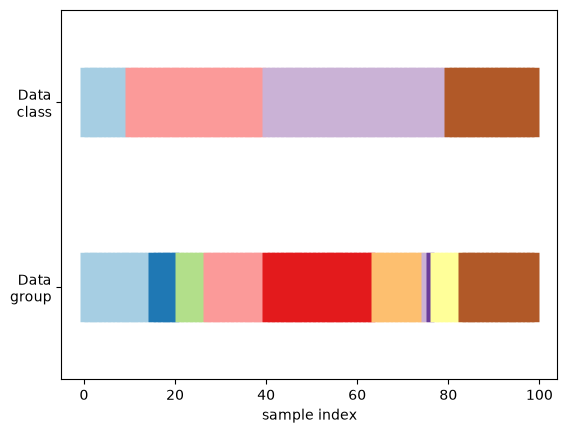

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    KFold,
    ShuffleSplit,
    StratifiedGroupKFold,
    StratifiedKFold,
    StratifiedShuffleSplit,
    TimeSeriesSplit
)

rng = np.random.RandomState(1338)
cmap_data = plt.cm.Paired
cmap_cv = plt.cm.coolwarm
n_splits = 5

n_points = 100
percentiles_classes = np.array([0.1, 0.3, 0.4, 0.2])

percentiles_classes = percentiles_classes / percentiles_classes.sum()
edges = np.round(np.cumsum(percentiles_classes) * n_points).astype(int)
counts = np.diff(edges, prepend=0)
y = np.repeat(np.arange(len(percentiles_classes)), counts)

X = rng.rand(n_points, 10)
group_prior = rng.dirichlet([2] * 10)
groups = np.repeat(np.arange(10), rng.multinomial(n_points, group_prior))


def visualize_groups(classes, groups, name):
    fix, ax = plt.subplots()
    ax.scatter(
        range(len(groups)),
        [0.5] * len(groups),
        c=groups,
        marker='_',
        lw=50,
        cmap=cmap_data
    )
    ax.scatter(
        range(len(groups)),
        [3.5] * len(groups),
        c=classes,
        marker='_',
        lw=50,
        cmap=cmap_data
    )
    ax.set(
        ylim=[-1, 5],
        yticks=[0.5, 3.5],
        yticklabels=['Data\ngroup', 'Data\nclass'],
        xlabel='sample index'
    )
visualize_groups(y, groups, 'no groups')

In [ ]:
def plot_cv_indices(cv, X, y, group, ax, n_splits, lw=10):
    use_groups= 'Group' in type(cv).__name__
    groups = group if use_groups else None
    for ii, (tr, tt) in enumerate(cv.split(X=X, y=y, groups=groups)):
        indices = np.array([np.nan] * len(X))
        indices[tt] = 1
        indices[tr] = 0

        ax.scatter(
            range(len(indices)),
            [ii + 0.5] * len(indices),
            c=indices,
            marker='_',
            lw=lw,
            cmap=cmap_cv,
            vmin=-0.2,
            vmax=1.2
        )

    ax.scatter(
        range(len(X)), [ii + 1.5] * len(X), c=y, marker='_', lw=lw, cmap=cmap_data
    )
    ax.scatter(
        range(len(X)), [ii + 2.5] * len(X), c=group, marker='_', lw=lw, cmap=cmap_data
    )

    yticklabels= list(range(n_splits)) + ['class', 'group']
    ax.set(
        yticks=np.arange(n_splits + 2) + 0.5,
        yticklabels=yticklabels,
        xlabel='sample index',
        ylabel='CV iteration',
        ylim=[n_splits + 2.2, -0.2],
        xlim=[0, 100]
    )
    ax.set_title('{}'.format(type(cv).__name__), fontsize=15)
    return ax

<Axes: title={'center': 'KFold'}, xlabel='sample index', ylabel='CV iteration'>

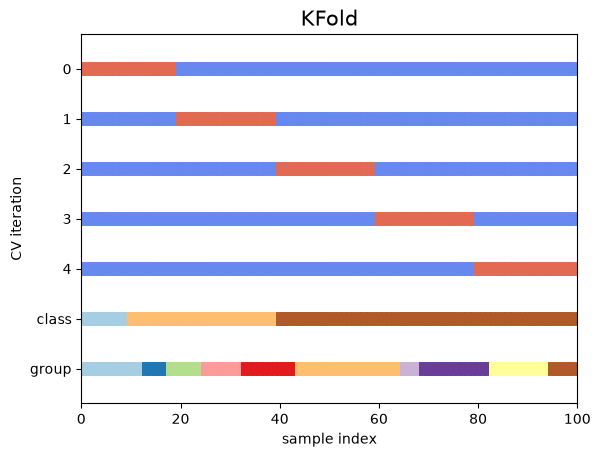

In [ ]:
fig, ax = plt.subplots()
cv = KFold(n_splits)
plot_cv_indices(cv, X, y, groups, ax, n_splits)

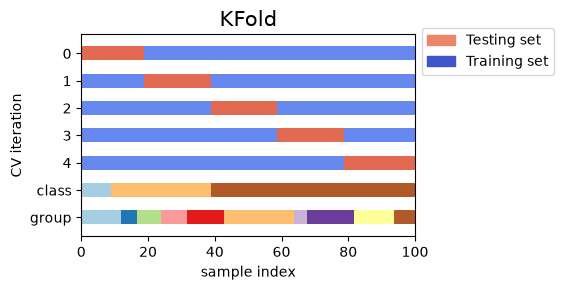

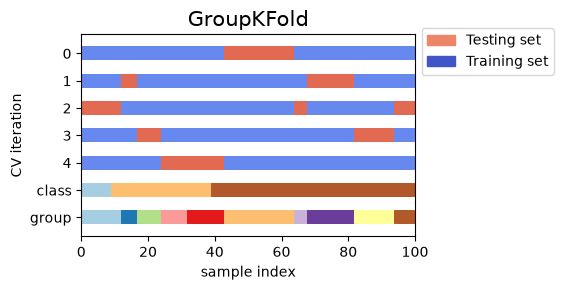

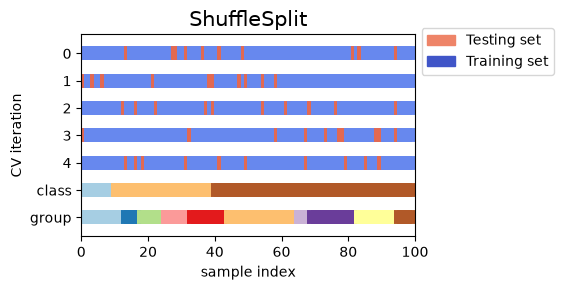

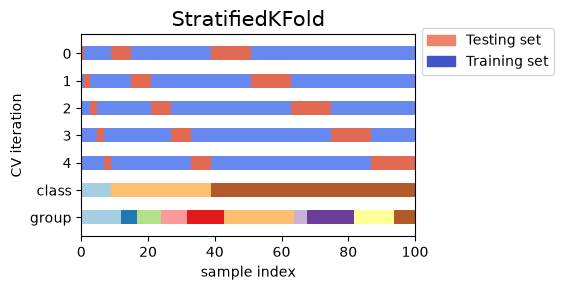

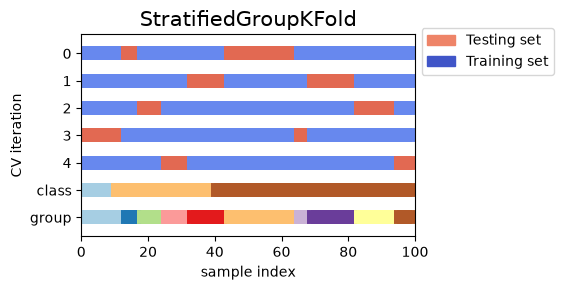

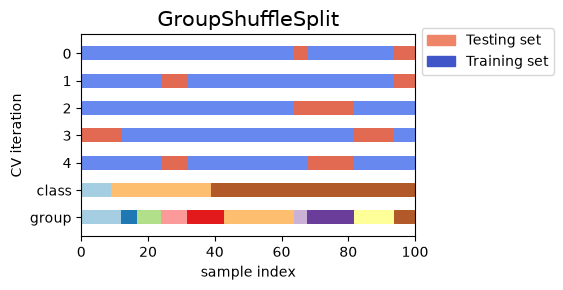

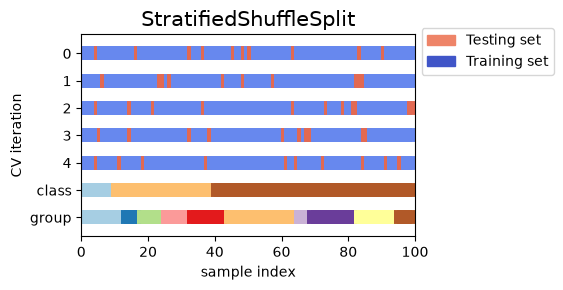

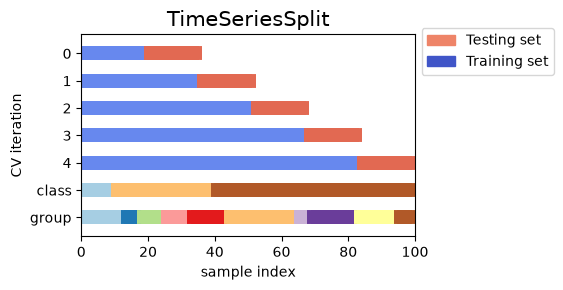

In [ ]:
cvs = [
    KFold,
    GroupKFold,
    ShuffleSplit,
    StratifiedKFold,
    StratifiedGroupKFold,
    GroupShuffleSplit,
    StratifiedShuffleSplit,
    TimeSeriesSplit
]

for cv in cvs:
    this_cv = cv(n_splits=n_splits)
    fig, ax = plt.subplots(figsize=(6, 3))
    plot_cv_indices(this_cv, X, y, groups, ax, n_splits)

    ax.legend(
        [Patch(color=cmap_cv(0.8)), Patch(color=cmap_cv(0.02))],
        ['Testing set', 'Training set'],
        loc=(1.02, 0.8)
    )

    plt.tight_layout()
    fig.subplots_adjust(right=0.7) 

plt.show() #